# Análisis de Ventas de una Tienda Minorista (Superstore)

## Objetivo

Analizar el conjunto de datos Superstore para identificar patrones de ventas, productos más vendidos, categorías más rentables y el impacto de los descuentos sobre las ganancias mediante Python y Pandas.

## Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Carga del conjunto de datos

Se usa una ruta relativa para que el notebook funcione en cualquier máquina, no solo en la original.

In [2]:
df = pd.read_csv("Superstore.csv", encoding="latin1")

## Exploración inicial de los datos

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
# Solo columnas numéricas relevantes para el negocio (se excluyen Row ID y Postal Code)
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,"9,994.00","9,994.00","9,994.00","9,994.00"
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,"-6,599.98"
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,"22,638.48",14.00,0.80,"8,399.98"


## Limpieza de datos

Se verifican nulos y duplicados, y se convierten las fechas a formato datetime.

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

## Columna de margen

Se agrega el margen de ganancia (`Profit / Sales`) para poder comparar rentabilidad relativa entre categorías, no solo en valores absolutos.

In [9]:
df["Margin"] = df["Profit"] / df["Sales"]

## Análisis de ventas y beneficios

In [10]:
total_ventas = df["Sales"].sum()
total_ganancia = df["Profit"].sum()
margen_general = total_ganancia / total_ventas

print(f"Ventas totales: {total_ventas:,.2f}")
print(f"Ganancia total: {total_ganancia:,.2f}")
print(f"Margen general: {margen_general:.2%}")

Ventas totales: 2,297,200.86
Ganancia total: 286,397.02
Margen general: 12.47%


## Ventas y rentabilidad por categoría

Se combina Sales, Profit y Margin en una sola tabla para comparar categorías de forma completa (antes se veían por separado, lo que dificultaba comparar volumen vs. rentabilidad).

In [11]:
resumen_categoria = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Margin=("Margin", "mean")
).sort_values("Profit", ascending=False)

resumen_categoria

,Sales,Profit,Margin
Category,,,
Technology,"836,154.03","145,454.95",0.16
Office Supplies,"719,047.03","122,490.80",0.14
Furniture,"741,999.80","18,451.27",0.04


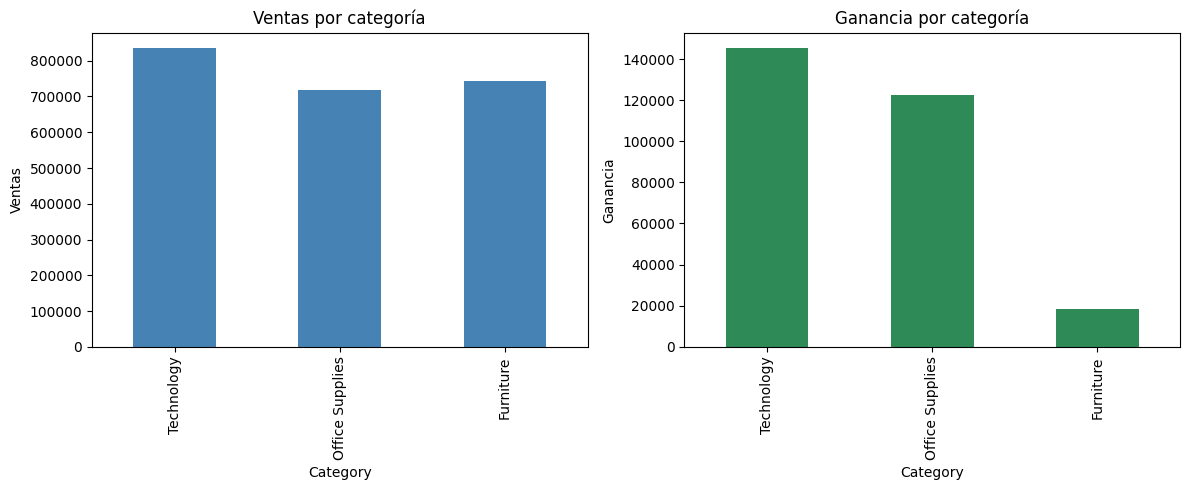

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

resumen_categoria["Sales"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Ventas por categoría")
axes[0].set_ylabel("Ventas")

resumen_categoria["Profit"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Ganancia por categoría")
axes[1].set_ylabel("Ganancia")

plt.tight_layout()
plt.show()

### Interpretación

Technology genera la mayor ganancia, pero Furniture, pese a tener ventas similares a Office Supplies, produce una fracción mucho menor de ganancia. Esto ya anticipa que el problema de Furniture no es de volumen sino de rentabilidad — algo que se confirma más adelante al cruzar con descuentos.

## Rentabilidad por sub-categoría

Se ordena por Profit (no por Sales) para identificar qué sub-categorías realmente destruyen valor.

In [13]:
resumen_subcat = df.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Profit")

resumen_subcat

,Sales,Profit
Sub-Category,,
Tables,"206,965.53","-17,725.48"
Bookcases,"114,880.00","-3,472.56"
Supplies,"46,673.54","-1,189.10"
Fasteners,"3,024.28",949.52
Machines,"189,238.63","3,384.76"
Labels,"12,486.31","5,546.25"
Art,"27,118.79","6,527.79"
Envelopes,"16,476.40","6,964.18"
Furnishings,"91,705.16","13,059.14"


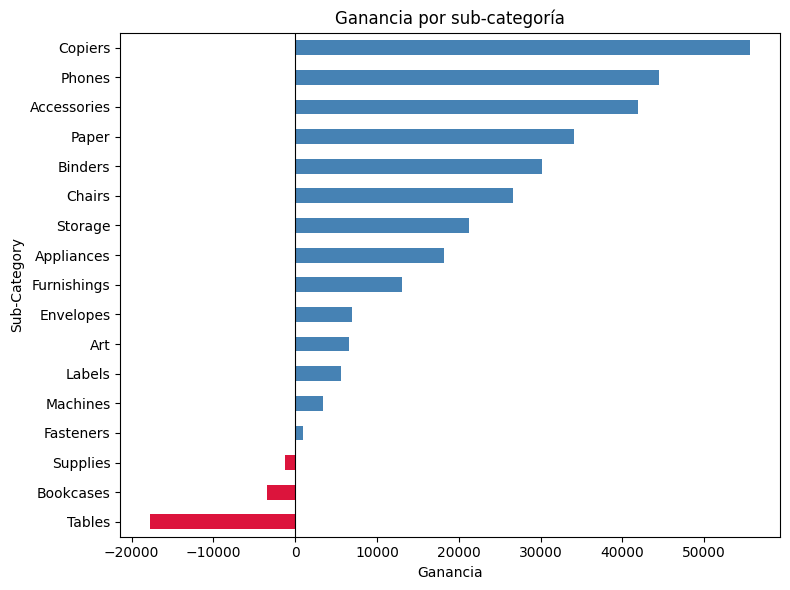

In [14]:
resumen_subcat["Profit"].plot(kind="barh", figsize=(8,6), color=resumen_subcat["Profit"].apply(lambda x: "crimson" if x < 0 else "steelblue"))
plt.title("Ganancia por sub-categoría")
plt.xlabel("Ganancia")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Interpretación

Tables y Bookcases son las únicas sub-categorías con ganancia negativa. Esto confirma por qué Furniture rinde tan poco pese a tener buen volumen de ventas.

## Rentabilidad por región

Se muestra la tabla ordenada explícitamente antes de graficar, para que la conclusión quede respaldada por datos y no solo por el gráfico.

In [15]:
ganancia_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
ganancia_region

Region
West      108,418.45
East       91,522.78
South      46,749.43
Central    39,706.36
Name: Profit, dtype: float64

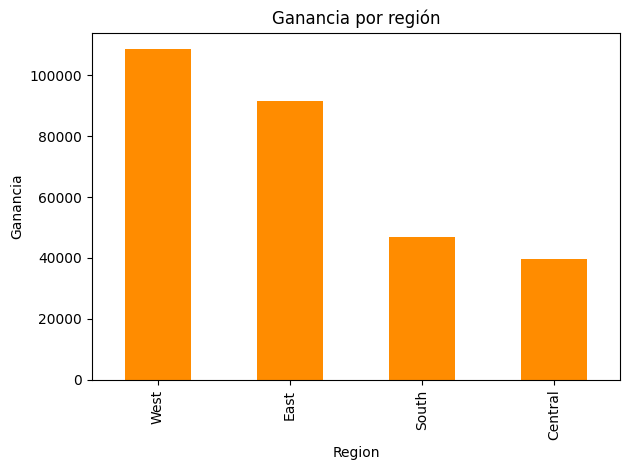

In [16]:
ganancia_region.plot(kind="bar", color="darkorange")
plt.title("Ganancia por región")
plt.ylabel("Ganancia")
plt.tight_layout()
plt.show()

### Interpretación

West es la región más rentable, seguida de East. Central y South generan bastante menos ganancia pese a formar parte del mismo mercado nacional, lo que sugiere revisar condiciones comerciales o mix de productos por región.

## Top 10 ciudades más rentables

In [17]:
df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(10)

City
New York City   62,036.98
Los Angeles     30,440.76
Seattle         29,156.10
San Francisco   17,507.39
Detroit         13,181.79
Lafayette       10,018.39
Jackson          7,581.68
Atlanta          6,993.66
Minneapolis      6,824.58
San Diego        6,377.20
Name: Profit, dtype: float64

## Evolución temporal de ventas

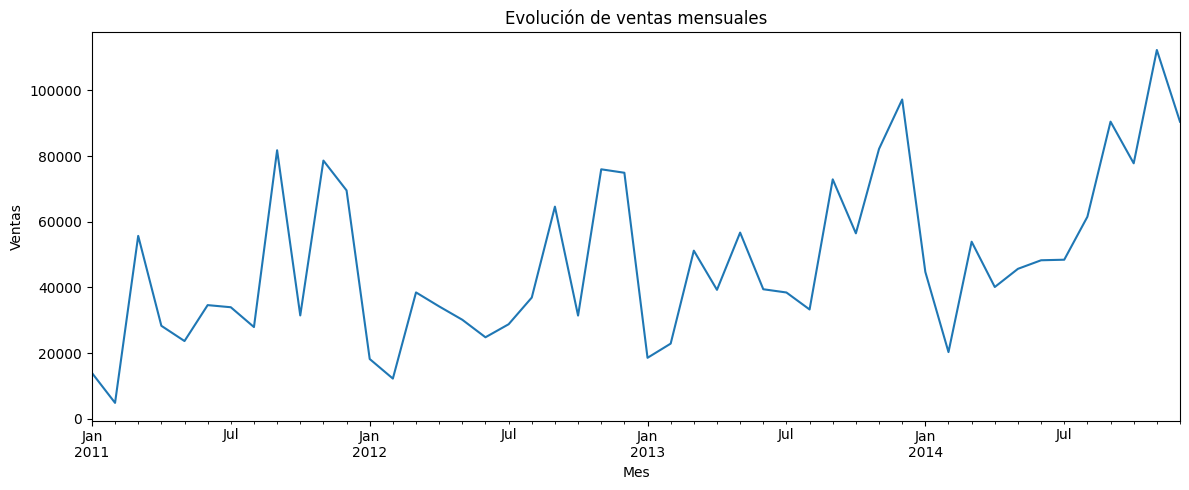

In [18]:
ventas_mes = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

ventas_mes.plot(figsize=(12,5))
plt.title("Evolución de ventas mensuales")
plt.ylabel("Ventas")
plt.xlabel("Mes")
plt.tight_layout()
plt.show()

### Interpretación

Se observa estacionalidad con picos hacia fin de año (noviembre-diciembre), consistente con temporada de compras. Sirve para planificar inventario y campañas.

## Relación entre descuentos y ganancias

Se reemplaza el scatter original por un boxplot: con tantos puntos superpuestos en los mismos niveles de descuento, el scatter no dejaba ver bien la distribución ni la mediana por nivel.

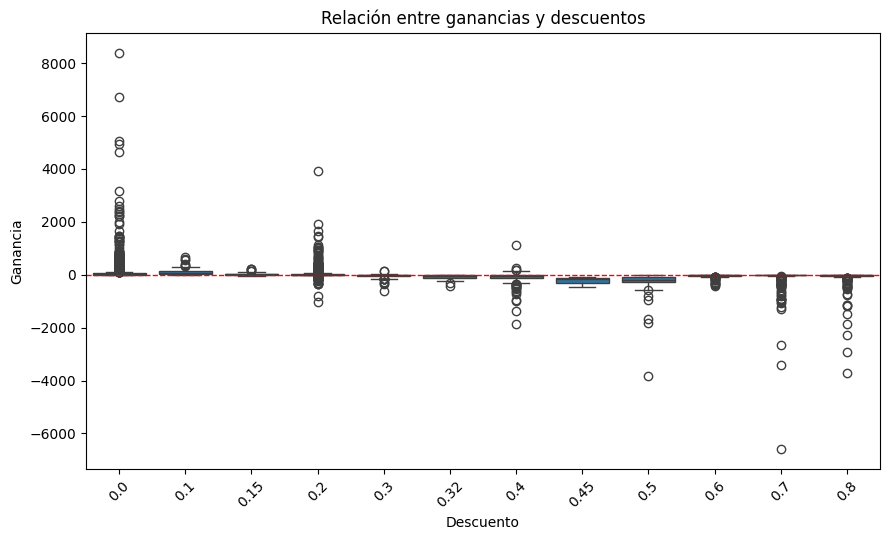

In [19]:
df["Discount"] = df["Discount"].round(2)

plt.figure(figsize=(9,5.5))
sns.boxplot(data=df, x="Discount", y="Profit")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Relación entre ganancias y descuentos")
plt.xlabel("Descuento")
plt.ylabel("Ganancia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación

A partir de un descuento de 0.3, la mediana de ganancia cae por debajo de cero: no es una tendencia suave sino un quiebre claro. Los descuentos de 0.5 en adelante son pérdida sistemática, no un caso aislado.

## ¿Qué categorías concentran los descuentos que queman margen?

Este cruce faltaba en la versión original: identificar en qué categorías se concentran los descuentos altos y su efecto en la ganancia.

In [20]:
descuento_categoria = df[df["Discount"] >= 0.3].groupby("Category").agg(
    Ordenes=("Discount", "count"),
    Descuento_promedio=("Discount", "mean"),
    Profit_total=("Profit", "sum")
).sort_values("Profit_total")

descuento_categoria

,Ordenes,Descuento_promedio,Profit_total
Category,,,
Furniture,542,0.43,"-54,477.76"
Office Supplies,680,0.74,"-47,140.14"
Technology,171,0.44,"-33,758.16"


### Interpretación

Al filtrar solo las ventas con descuento igual o mayor a 0.3, queda claro qué categoría concentra más pérdidas por esta política de descuentos, y permite decidir si conviene limitar el descuento máximo en esa categoría específica.

## Top y bottom 10 productos por rentabilidad

Se agrega este análisis: el original solo miraba ventas, nunca rentabilidad a nivel producto.

In [21]:
rentabilidad_producto = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False)

print("Top 10 productos más rentables:")
display(rentabilidad_producto.head(10))

print("\nTop 10 productos con mayor pérdida:")
display(rentabilidad_producto.tail(10))

Top 10 productos más rentables:


Product Name
Canon imageCLASS 2200 Advanced Copier                                         25,199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    7,753.04
Hewlett Packard LaserJet 3310 Copier                                           6,983.88
Canon PC1060 Personal Laser Copier                                             4,570.93
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      4,094.98
Ativa V4110MDD Micro-Cut Shredder                                              3,772.95
3D Systems Cube Printer, 2nd Generation, Magenta                               3,717.97
Plantronics Savi W720 Multi-Device Wireless Headset System                     3,696.28
Ibico EPK-21 Electric Binding System                                           3,345.28
Zebra ZM400 Thermal Label Printer                                              3,343.54
Name: Profit, dtype: float64


Top 10 productos con mayor pérdida:


Product Name
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1,148.44
Balt Solid Wood Round Tables                                        -1,201.06
Martin Yale Chadless Opener Electric Letter Opener                  -1,299.18
Cisco TelePresence System EX90 Videoconferencing Unit               -1,811.08
GBC DocuBind P400 Electric Binding System                           -1,878.17
Bush Advantage Collection Racetrack Conference Table                -1,934.40
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2,876.12
Cubify CubeX 3D Printer Triple Head Print                           -3,839.99
Lexmark MX611dhe Monochrome Laser Printer                           -4,589.97
Cubify CubeX 3D Printer Double Head Print                           -8,879.97
Name: Profit, dtype: float64

## Detección de outliers en ganancia

Se identifican valores extremos que no fueron discutidos en la versión original, para descartar errores de carga antes de sacar conclusiones.

In [22]:
q1 = df["Profit"].quantile(0.25)
q3 = df["Profit"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df[(df["Profit"] < limite_inferior) | (df["Profit"] > limite_superior)]
print(f"Cantidad de outliers detectados: {len(outliers)} ({len(outliers)/len(df):.1%} del total)")

outliers[["Product Name", "Category", "Discount", "Profit"]].sort_values("Profit").head(10)

Cantidad de outliers detectados: 1881 (18.8% del total)


,Product Name,Category,Discount,Profit
7772,Cubify CubeX 3D Printer Double Head Print,Technology,0.70,"-6,599.98"
683,Cubify CubeX 3D Printer Triple Head Print,Technology,0.50,"-3,839.99"
9774,GBC DocuBind P400 Electric Binding System,Office Supplies,0.80,"-3,701.89"
3011,Lexmark MX611dhe Monochrome Laser Printer,Technology,0.70,"-3,399.98"
4991,Ibico EPK-21 Electric Binding System,Office Supplies,0.80,"-2,929.48"
3151,Cubify CubeX 3D Printer Double Head Print,Technology,0.70,"-2,639.99"
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,0.80,"-2,287.78"
9639,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,0.40,"-1,862.31"
1199,GBC DocuBind P400 Electric Binding System,Office Supplies,0.80,"-1,850.95"
2697,Cisco TelePresence System EX90 Videoconferenci...,Technology,0.50,"-1,811.08"


### Interpretación

Antes de descartarlos, conviene revisar si estos outliers son ventas reales con condiciones excepcionales (grandes pedidos, descuentos puntuales negociados) o errores de carga. En este dataset son ventas reales, así que se mantienen en el análisis pero se documentan como casos atípicos.

# Hallazgos principales

- Technology es la categoría más rentable en términos absolutos; Furniture tiene ventas comparables a Office Supplies pero rentabilidad mucho menor.
- Tables y Bookcases son las únicas sub-categorías con ganancia negativa acumulada.
- West es la región más rentable, confirmado con la tabla ordenada de `groupby`.
- A partir de un descuento de 0.3 la mediana de ganancia se vuelve negativa: no es una relación lineal suave, es un quiebre.
- Existe una categoría concentrando la mayoría de las pérdidas por descuentos altos (ver sección de cruce descuento-categoría).
- Se identificaron y documentaron outliers en ganancia sin descartarlos arbitrariamente.

# Conclusiones

El análisis muestra que el volumen de ventas no es un buen proxy de rentabilidad: hay categorías y sub-categorías con ventas altas pero ganancia baja o negativa. La política de descuentos actual, en particular a partir de 0.3, está asociada con pérdidas sistemáticas y debería revisarse por categoría en lugar de aplicarse de forma uniforme. Este proyecto demuestra cómo el análisis de datos con Pandas permite pasar de una descripción superficial (qué se vendió más) a un diagnóstico accionable (qué está perdiendo dinero y por qué).